## Mini Project 3 Notebook

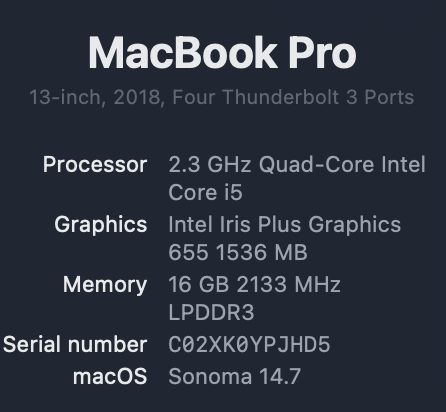

### Section 1: Numerical Accuracy

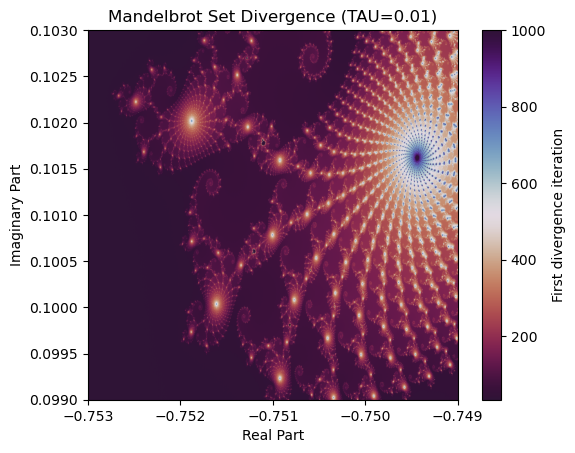

In [1]:
from helper_funcs.precision_helpers import mandelbrot_divergence, mandelbrot_sensitivity
from matplotlib import pyplot as plt

divergence = mandelbrot_divergence(max_iters=1000, x_set=(-0.750, -0.747), y_set=(0.099, 0.101))

Max sensitivity (kappa) at index: (np.int64(676), np.int64(132))
Max sensitivity (kappa): 9.19e+07


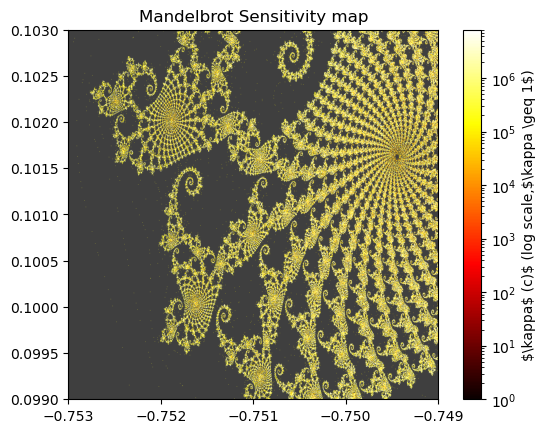

In [2]:
divergence = mandelbrot_sensitivity(max_iters=1000, x_set=(-0.750, -0.747), y_set=(0.099, 0.101), win_size=1024)

The values with the highest sensitivty seem to be on the outside edge of the seahorse tails and some high values also seen in the seahorses themselves. This is consistent mostly with the divergence, where those with a higher divergence value are normally in these areas of higher sensitivity

### Section 2: Testing

In [4]:
!python -m pytest -q --tb=short > test_output.txt
with open("test_output.txt", "r") as f:
    test_output = f.read()
print(test_output)
!rm test_output.txt

........................................................................ [ 65%]
......................................                                   [100%]
110 passed in 19.66s



Coverage: 

main.py: 53% \
helper_funcs/multiprocessing_helpers.py: 54% \
helper_funcs/distributed_helpers.py: 44% 

Note - These files also contain code not used in the project, as well as helper functions.

#### Output of type checking
Note: prange is iterable and other warnings are not currently fixable

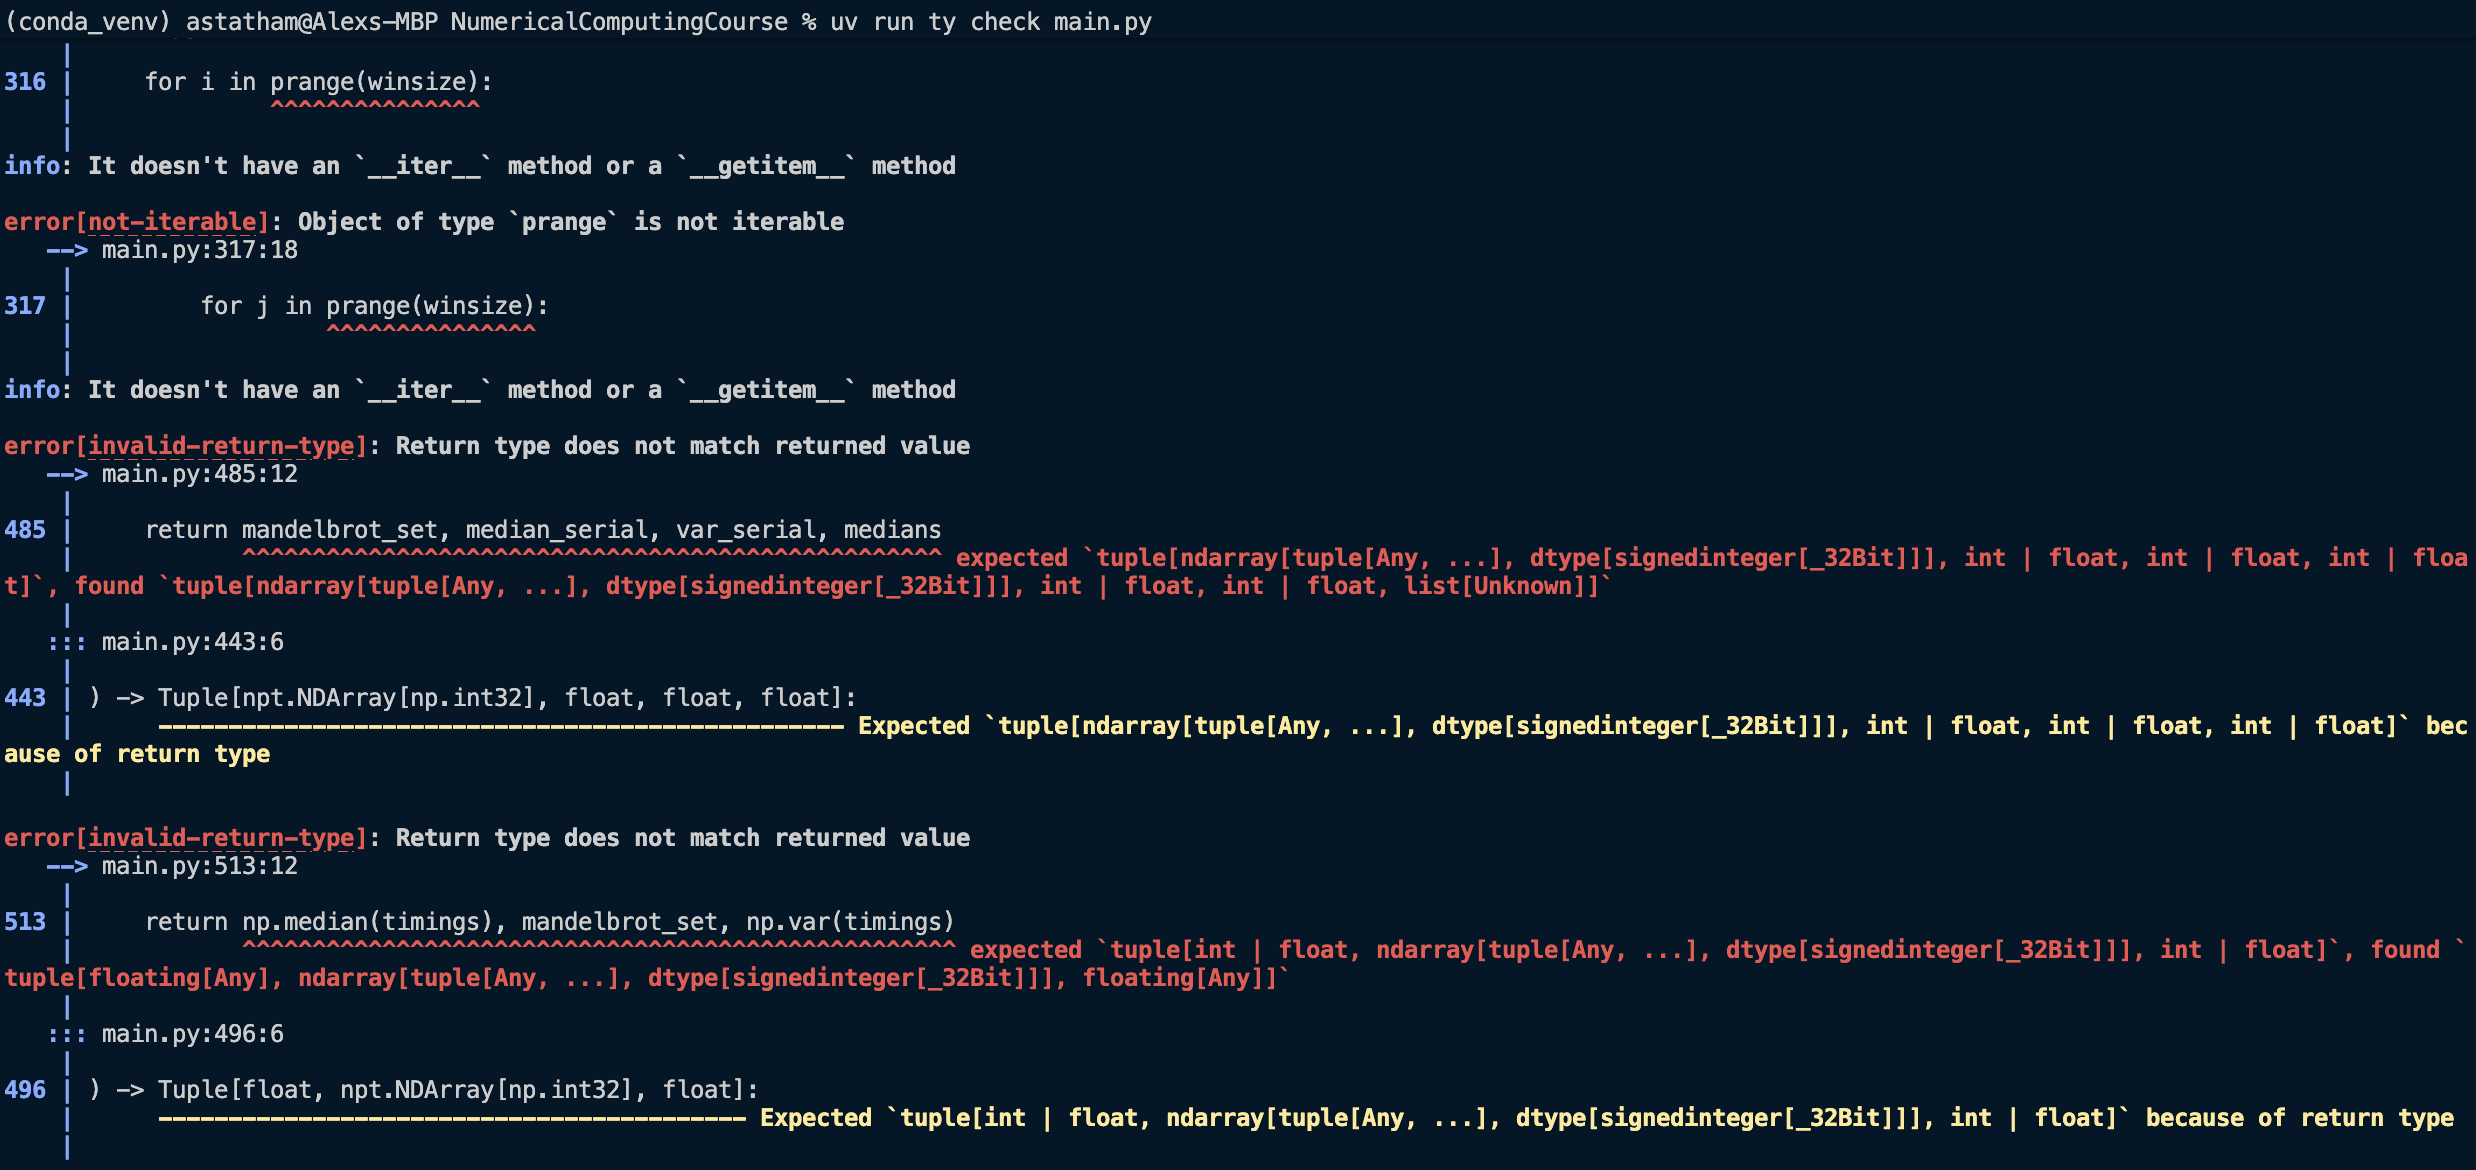

#### Ruff checks
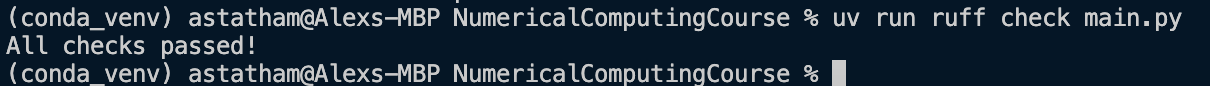

#### Final comments
Tests of main functions from week 1-6 are covered, as well as timing checks for week 1-5 as dask local can be incosistent. 

### Section 3: GPU programming
NOTE: f64 does not produce the correct output on my hardware

In [1]:
import pyopencl as cl
platforms = cl.get_platforms()
gpu_devices = platforms[0].get_devices(device_type=cl.device_type.GPU)
print("Available GPU devices:")
for device in gpu_devices:
    print(f"- {device.name}")


Available GPU devices:
- Intel(R) Iris(TM) Plus Graphics 655


GPU Mandelbrot computed in 0.0683 seconds
GPU Mandelbrot computed in 0.0300 seconds
GPU Mandelbrot computed in 0.0368 seconds
GPU Mandelbrot computed in 0.1166 seconds
GPU Mandelbrot computed in 0.1071 seconds
GPU Mandelbrot computed in 0.0954 seconds


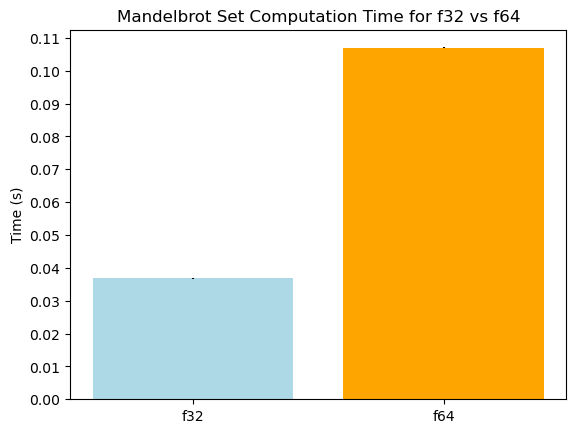

In [18]:
from main import w10_main
from matplotlib import pyplot as plt
import numpy as np
f32, mf32, var32 = w10_main(win_size=4096)
f64, mf64, var64 = w10_main(win_size=4096, use_f64=True)

plt.bar(["f32", "f64"], [f32, f64], yerr=[var32, var64], color=["lightblue", "orange"])
plt.ylabel("Time (s)")
plt.title("Mandelbrot Set Computation Time for f32 vs f64")
plt.yticks(np.linspace(0, round(max(f32, f64), 2), num=int(round(max(f32, f64), 2) / 0.01) + 1))
plt.show()

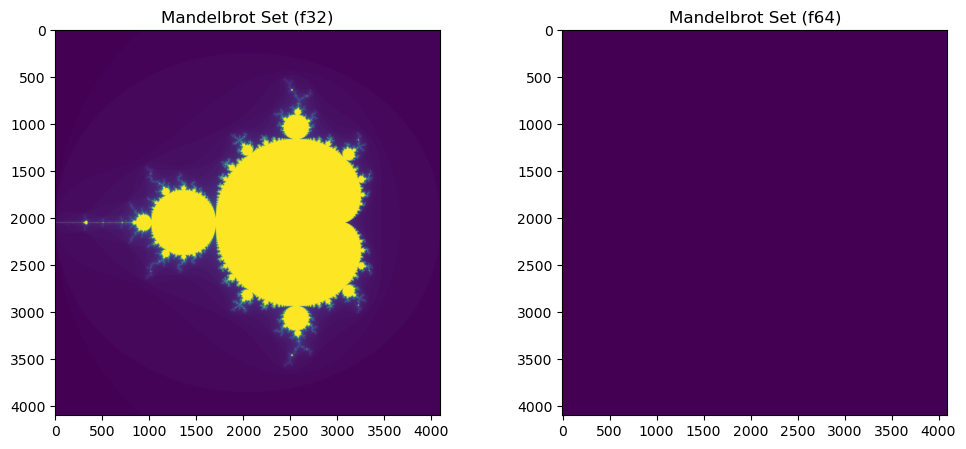

In [3]:
plt.subplots(1, 2, figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(mf32)
plt.title("Mandelbrot Set (f32)")
plt.subplot(1, 2, 2)
plt.imshow(mf64)
plt.title("Mandelbrot Set (f64)")
plt.show()

GPU Mandelbrot computed in 0.0085 seconds
GPU Mandelbrot computed in 0.0088 seconds
GPU Mandelbrot computed in 0.0074 seconds
GPU Mandelbrot computed in 0.0186 seconds
GPU Mandelbrot computed in 0.0135 seconds
GPU Mandelbrot computed in 0.0136 seconds
GPU Mandelbrot computed in 0.0182 seconds
GPU Mandelbrot computed in 0.0132 seconds
GPU Mandelbrot computed in 0.0173 seconds
GPU Mandelbrot computed in 0.0320 seconds
GPU Mandelbrot computed in 0.0311 seconds
GPU Mandelbrot computed in 0.0362 seconds
GPU Mandelbrot computed in 0.0406 seconds
GPU Mandelbrot computed in 0.0351 seconds
GPU Mandelbrot computed in 0.0434 seconds
GPU Mandelbrot computed in 0.1149 seconds
GPU Mandelbrot computed in 0.0930 seconds
GPU Mandelbrot computed in 0.1028 seconds
GPU Mandelbrot computed in 0.0863 seconds
GPU Mandelbrot computed in 0.0825 seconds
GPU Mandelbrot computed in 0.0821 seconds
GPU Mandelbrot computed in 0.2640 seconds
GPU Mandelbrot computed in 0.2245 seconds
GPU Mandelbrot computed in 0.2226 

/var/folders/5r/kbs2kcj51x30krhblbggj2d80000gn/T/ipykernel_30285/909422873.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


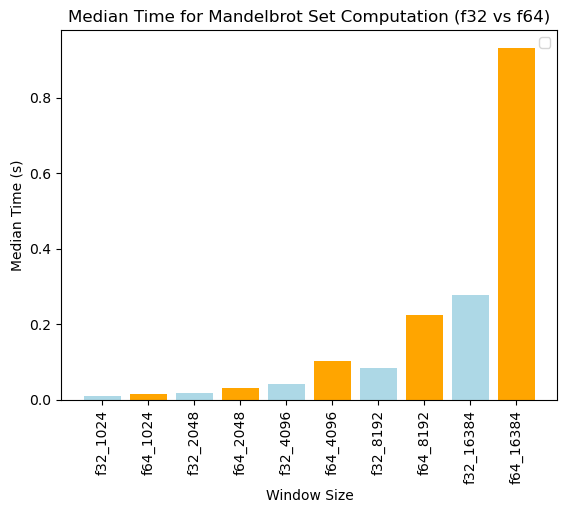

In [22]:
medians_dict = {}
for size in [1024, 2048, 4096, 8192, 16384]:
    f32, _, _ = w10_main(win_size=size)
    f64, _, _ = w10_main(win_size=size, use_f64=True)
    medians_dict[f"f32_{size}"] = f32
    medians_dict[f"f64_{size}"] = f64

plt.bar(medians_dict.keys(), medians_dict.values(), color=["lightblue" if "f32" in key else "orange" for key in medians_dict.keys()])
plt.xlabel("Window Size")
plt.ylabel("Median Time (s)")
plt.title("Median Time for Mandelbrot Set Computation (f32 vs f64)")
plt.xticks(list(medians_dict.keys()))
plt.xticks(rotation=90)
plt.legend()
plt.show()

#### Final comments
where does GPU sit in the overall speedup progression? Any surprising result?
GPU is by far the fastest, this is expected due to the repetitive nature of mandelbrot calculations. I am surprised by the sizeable differences between f32 and f64, I assumed these would be smaller (2x at most), however, this may also have to do with emulation of f64 on my graphics device.

### All runs
NOTE: GPU f64 does not work on my graphics chip and therefore is not included

In [39]:
import pandas as pd
import numpy
from main import benchmark_all
d = benchmark_all(n_runs=3, size=1024)

df = pd.DataFrame(
    [
        d.get("w1_median"),
        d.get("w2_median"),
        d.get("w3_f32_median"),
        d.get("w3_f64_median"),
        d.get("w4_median"),
        d.get("w5_median"),
        d.get("w6_median"),
        d.get("w10_median"),
    ]
)

Week 1: Naive python implementation
Execution took: 8.061784 seconds
Execution took: 7.866600 seconds
Execution took: 7.363214 seconds
Median execution time over 3 runs: 7.867740 seconds
Week 2: numpy vectorization
Execution took: 0.802417 seconds
Execution took: 0.952116 seconds
Execution took: 0.774730 seconds
Median execution time over 3 runs: 0.828039 seconds
Week 3: Naive numba
Execution took: 0.643882 seconds
Execution took: 0.770750 seconds
Execution took: 0.673010 seconds
Median execution time over 3 runs: 0.673155 seconds
Week 3: optimized numba
Execution took: 0.089876 seconds
Execution took: 0.088770 seconds
Execution took: 0.082511 seconds
Median execution time over 3 runs: 0.100043 seconds
Execution took: 0.086780 seconds
Execution took: 0.085426 seconds
Execution took: 0.084764 seconds
Median execution time over 3 runs: 0.090487 seconds
Week 4: parallel computing
w4 median_w4 0.0338446909954655, 
w4 variance 6.263164887281792e-06
Week 5: parallel computing with pools
Medi

/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            ctx, src, options_bytes, devices, cache_dir,
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            include_path=include_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^~~
            uuid4().hex)
            ~~~~~~~~~~~~

### 1024x1024 grid

In [40]:

df.columns = ["Timings"]
df["Weeks"] = ["Naive", "Numpy", "Numba f32", "Numba f64", "Parallel", "Parallel Pooling", "Dask local", "GPU"]
naive = df["Timings"][0]
df["Speedup vs Numba f32"] = df["Timings"][2] / df["Timings"]

df = df[["Weeks", "Timings", "Speedup vs Numba f32", ]]
df

,Weeks,Timings,Speedup vs Numba f32
0,Naive,7.867740,0.011501
1,Numpy,0.828039,0.109279
2,Numba f32,0.090487,1.000000
3,Numba f64,0.100043,0.904483
4,Parallel,0.033845,2.673599
5,Parallel Pooling,0.021075,4.293520
6,Dask local,0.222472,0.406734
7,GPU,0.007890,11.469301


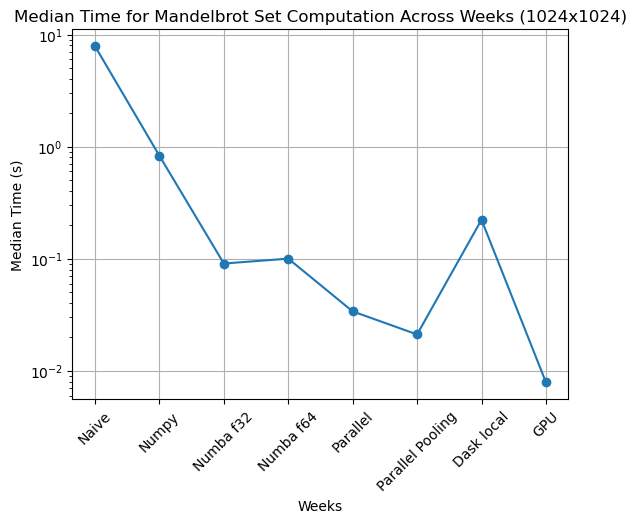

In [44]:
plt.plot(df["Weeks"], df["Timings"], marker="o")
plt.xlabel("Weeks")
plt.ylabel("Median Time (s)")
plt.title("Median Time for Mandelbrot Set Computation Across Weeks (1024x1024)")
plt.xticks(rotation=45)
plt.yscale("log")
plt.grid()
plt.show()

In [41]:

import pandas as pd
from main import benchmark_dtype, bennchmark_parallel

median_w3_f64, _, median_w3_f32, _, var_w3_f64, var_w3_f32 = benchmark_dtype(n_runs=3, win_size=4096)
parallel_dict = bennchmark_parallel(n_runs=3, size=4096)
df_parallel = pd.DataFrame(
    [
        median_w3_f32,
        median_w3_f64,
        parallel_dict.get("w4_median"),
        parallel_dict.get("w5_median"),
        parallel_dict.get("w6_median"),
        parallel_dict.get("w10_median"),
    ]
)

Execution took: 1.648608 seconds
Execution took: 1.497403 seconds
Execution took: 1.392395 seconds
Median execution time over 3 runs: 1.893153 seconds
Execution took: 1.536232 seconds
Execution took: 1.497993 seconds
Execution took: 1.367525 seconds
Median execution time over 3 runs: 1.584258 seconds
Week 4: parallel computing
w4 median_w4 0.6797136289969785, 
w4 variance 0.017190337586852563
Week 5: parallel computing with pools
Median execution time over 4 runs: 1.329931 seconds
Median time for w5: 0.45415376399614615, 
w5 variance 0.8486459142062627
Week 6: Dask local
Dashboard: http://127.0.0.1:8787/status
median time for dask worker: 0.5311242000025231
Execution for serial took: 1.410264 seconds
Median time for w6: 0.5311242000025231, 
w6 variance 0.0015849116619984303
Week 10: GPU with OPENcl (f32)
GPU Mandelbrot computed in 0.0462 seconds
GPU Mandelbrot computed in 0.0388 seconds


/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            ctx, src, options_bytes, devices, cache_dir,
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
            include_path=include_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^~~
            uuid4().hex)
            ~~~~~~~~~~~~

GPU Mandelbrot computed in 0.0341 seconds
Median time for w10: 0.03876943099749042, 
w10 variance 2.457067903073529e-05
Week 10: GPU with OPENcl (f64)
GPU Mandelbrot computed in 0.1081 seconds


/Users/astatham/Documents/Development/NumericalComputingCourse/helper_funcs/gpu_helpers.py:171: RepeatedKernelRetrieval: Kernel 'mandelbrot_f64' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog.mandelbrot_f64(


GPU Mandelbrot computed in 0.1056 seconds
GPU Mandelbrot computed in 0.1054 seconds
Median time for w10 (f64): 0.10556166499736719, 
w10 variance (f64) 1.5511895114922746e-06


### Speedup on 4096x4096

In [42]:
df_parallel.columns = ["Timings"]
df_parallel["Weeks"] = ["Numba f32", "Numba f64", "Parallel", "Parallel Pooling", "Dask local", "GPU f32"]
naive = df_parallel["Timings"][0]
df_parallel["Speedup vs Numba f32"] = df_parallel["Timings"][0] / df_parallel["Timings"]

df_parallel = df_parallel[["Weeks", "Timings", "Speedup vs Numba f32", ]]
df_parallel

,Weeks,Timings,Speedup vs Numba f32
0,Numba f32,1.584258,1.000000
1,Numba f64,1.893153,0.836836
2,Parallel,0.679714,2.330773
3,Parallel Pooling,0.454154,3.488374
4,Dask local,0.531124,2.982839
5,GPU f32,0.038769,40.863592


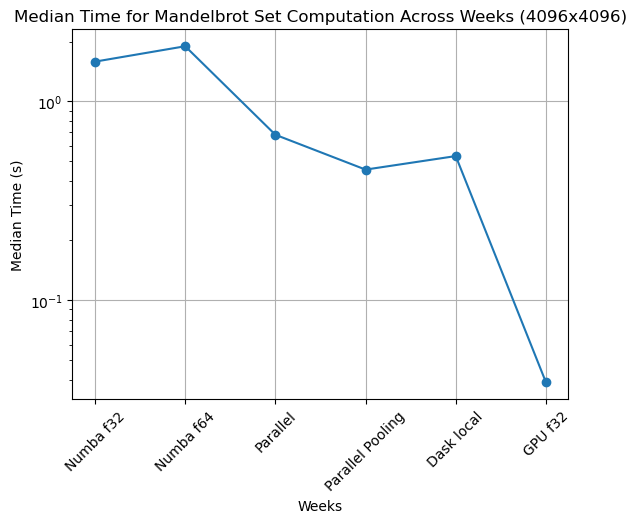

In [43]:
plt.plot(df_parallel["Weeks"], df_parallel["Timings"], marker="o")
plt.xlabel("Weeks")
plt.ylabel("Median Time (s)")
plt.title("Median Time for Mandelbrot Set Computation Across Weeks (4096x4096)")
plt.xticks(rotation=45)
plt.yscale("log")
plt.grid()
plt.show()

Small note: dask local has in previous MP outperformed parallel pooling at 4096, however, does not seem to be now. I am unsure why.